[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


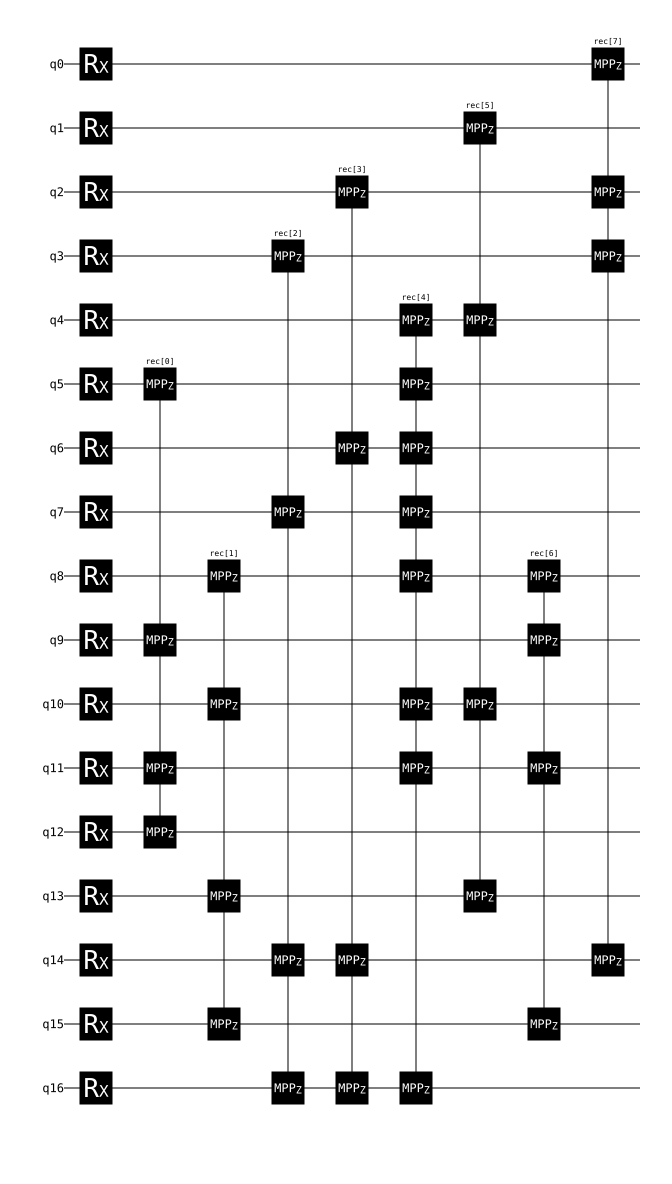

In [1]:
import stim
from spiderwarp.csscode import CSSCode
import numpy as np

code_name, circuit_path = "17_1_5", "cc_4_8_8_d5/zero_ft_heuristic_opt"
code = CSSCode.load_code("MQT", code_name)

perfect_state = stim.Circuit()
perfect_state.append("RX", range(len(code.H_x[0]) ))
for row in code.H_z:  # Note: H_x, not H_z
    targets = []
    support = [i for i, r in enumerate(row) if r == 1]
    for q in support:
        targets.append(stim.target_z(q))
        targets.append(stim.target_combiner())
    if targets:
        targets.pop()
        perfect_state.append("MPP", targets)

test = perfect_state.copy()
test.append("MX", range(code.n))
print(test.compile_sampler().sample(10)[:,-code.n:] @ code.H_x.T % 2)
perfect_state.diagram('timeline-svg')


Number of ancilla qubits necessary: 30


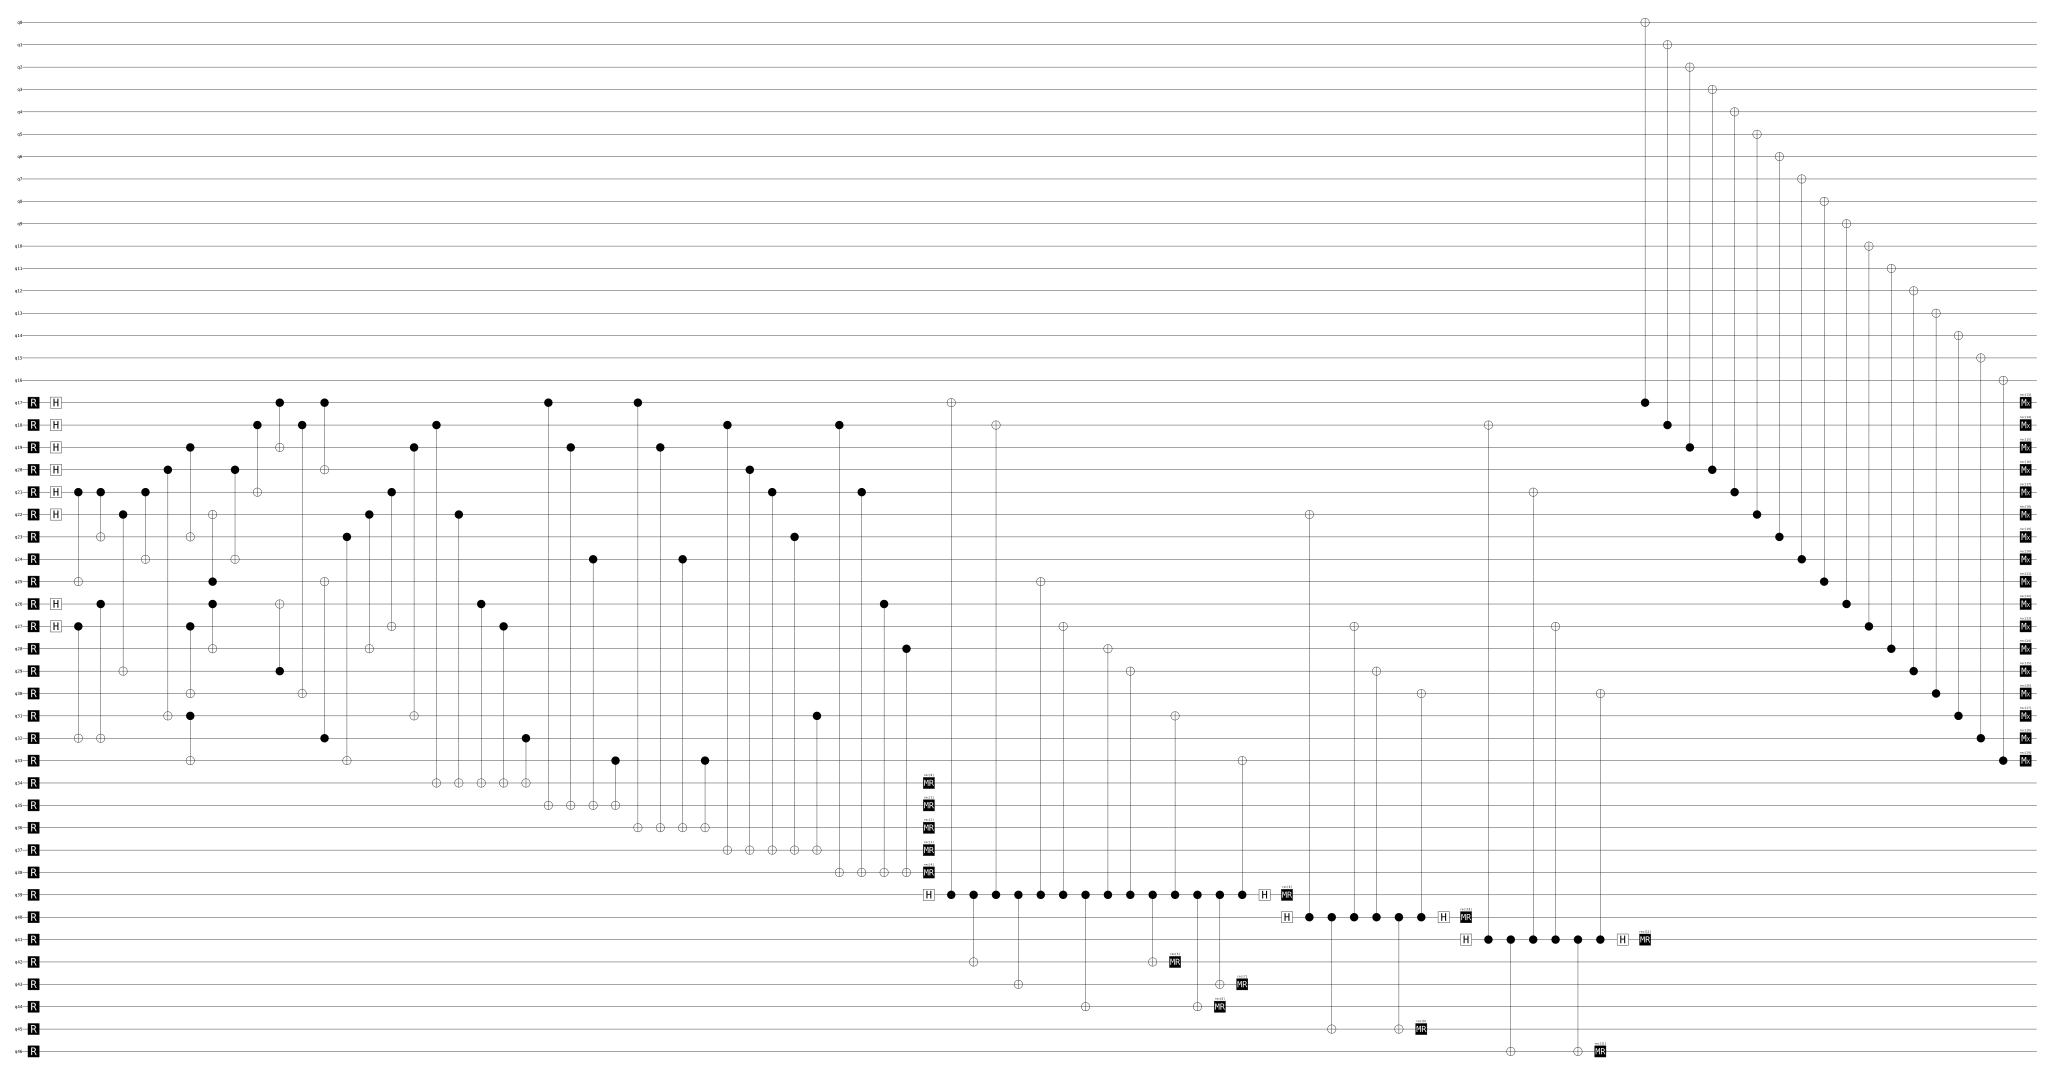

In [2]:
from spiderwarp.utils import load_state_prep_circuit, steane_se_from_stim_state_prep

circuit = load_state_prep_circuit("SAT", circuit_path)
se = steane_se_from_stim_state_prep(circuit, se_basis="Z", n=code.n)

print("Number of ancilla qubits necessary:", se.num_qubits - code.n)
se.diagram('timeline-svg')

In [3]:
samples = (perfect_state + se).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]
print(samples[:,:-code.n].astype(int))
print(samples[:,-code.n:] @ code.H_z.T % 2)

[[0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


Number of ancilla qubits necessary: 28
Mapping of new measurements to old measurements: {0: 1, 1: 15, 2: 2, 3: 20, 4: 13, 5: 0, 6: 28, 7: 3, 8: 19, 9: 4, 10: 22, 11: 14, 12: 17, 13: 21, 14: 11, 15: 23, 16: 24, 17: 5, 18: 9, 19: 10, 20: 25, 21: 6, 22: 12, 23: 27, 24: 7, 25: 8, 26: 26, 27: 29}


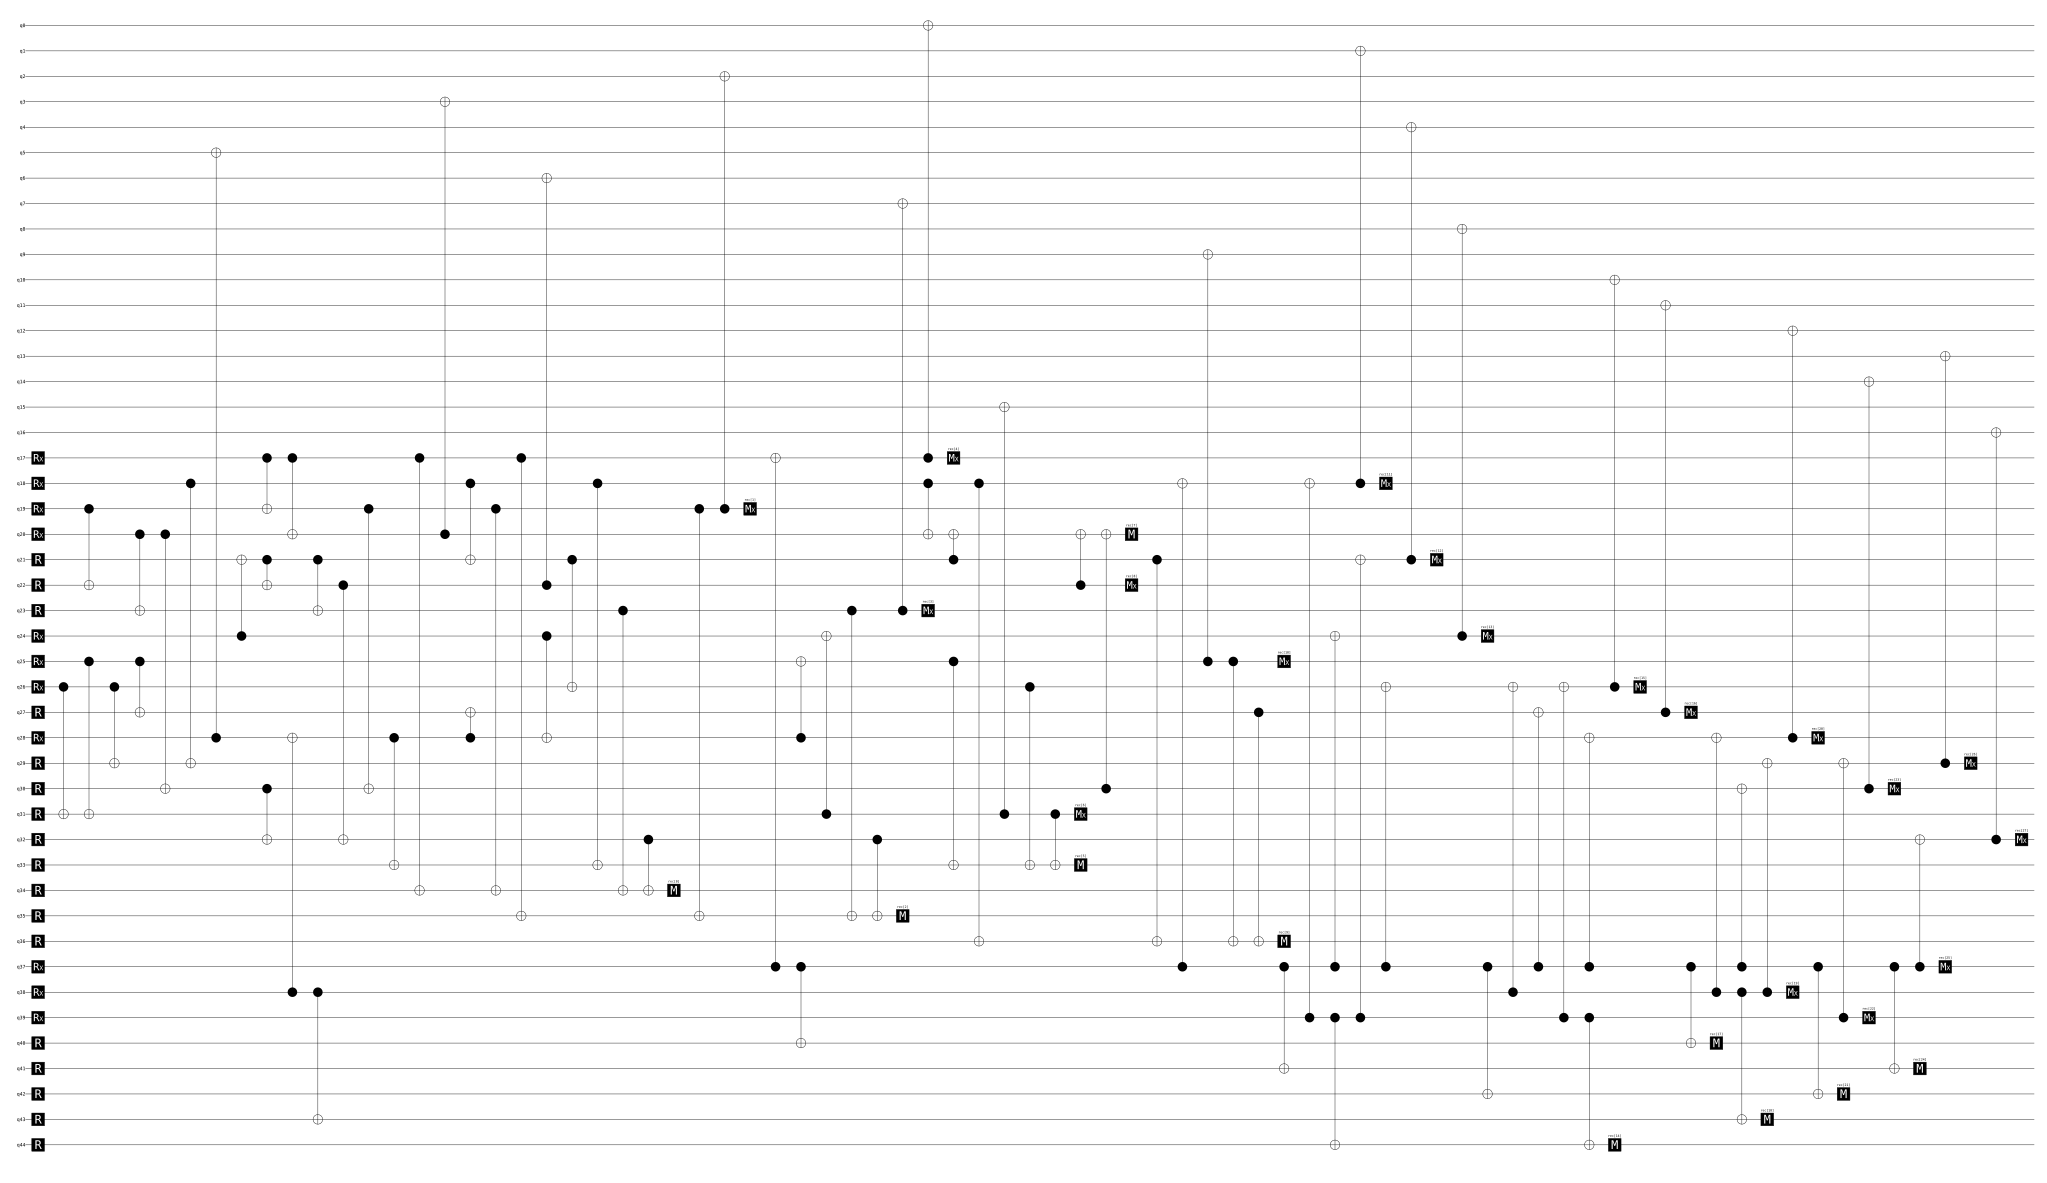

In [4]:
from spiderwarp.path_cover_opt import CoveredZXGraph, metric_spacetime_volume_exact


covered = CoveredZXGraph.from_stim(se)
covered.basic_FE_rewrites()
optimised = covered.mcts_boundary_bends(
    cost_func=metric_spacetime_volume_exact,
    max_iterations=100,
    rollout_depth=32,
    seed=0,
)
new_circuit, measurement_map = optimised.extract_circuit_with_measurement_map()

print("Number of ancilla qubits necessary:", new_circuit.num_qubits - code.n)
print("Mapping of new measurements to old measurements:", measurement_map)
new_circuit.diagram('timeline-svg')

In [5]:
samples = (perfect_state + new_circuit).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]

flag_indices = [k for k, v in measurement_map.items() if v < se.num_qubits - 2 * code.n]
flags = samples[:,flag_indices].astype(int)

syndrome_indices = {k:v - se.num_qubits + 2 * code.n for k, v in measurement_map.items() if v >= se.num_qubits - 2 * code.n}
effective_H = code.H_z[:,list(syndrome_indices.values())]
raw_syndrome_measurements = samples[:,list(syndrome_indices.keys())]
syndromes = raw_syndrome_measurements @ effective_H.T % 2

print("Flags:", flags, sep="\n", end="\n\n")

print("Syndromes:", syndromes, sep="\n")

Flags:
[[0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]]

Syndromes:
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


Number of ancilla qubits necessary: 24
Mapping of new measurements to old measurements: {0: 1, 1: 15, 2: 13, 3: 2, 4: 20, 5: 19, 6: 0, 7: 28, 8: 3, 9: 22, 10: 4, 11: 14, 12: 21, 13: 17, 14: 24, 15: 11, 16: 23, 17: 5, 18: 9, 19: 25, 20: 6, 21: 27, 22: 10, 23: 7, 24: 12, 25: 8, 26: 26, 27: 29}


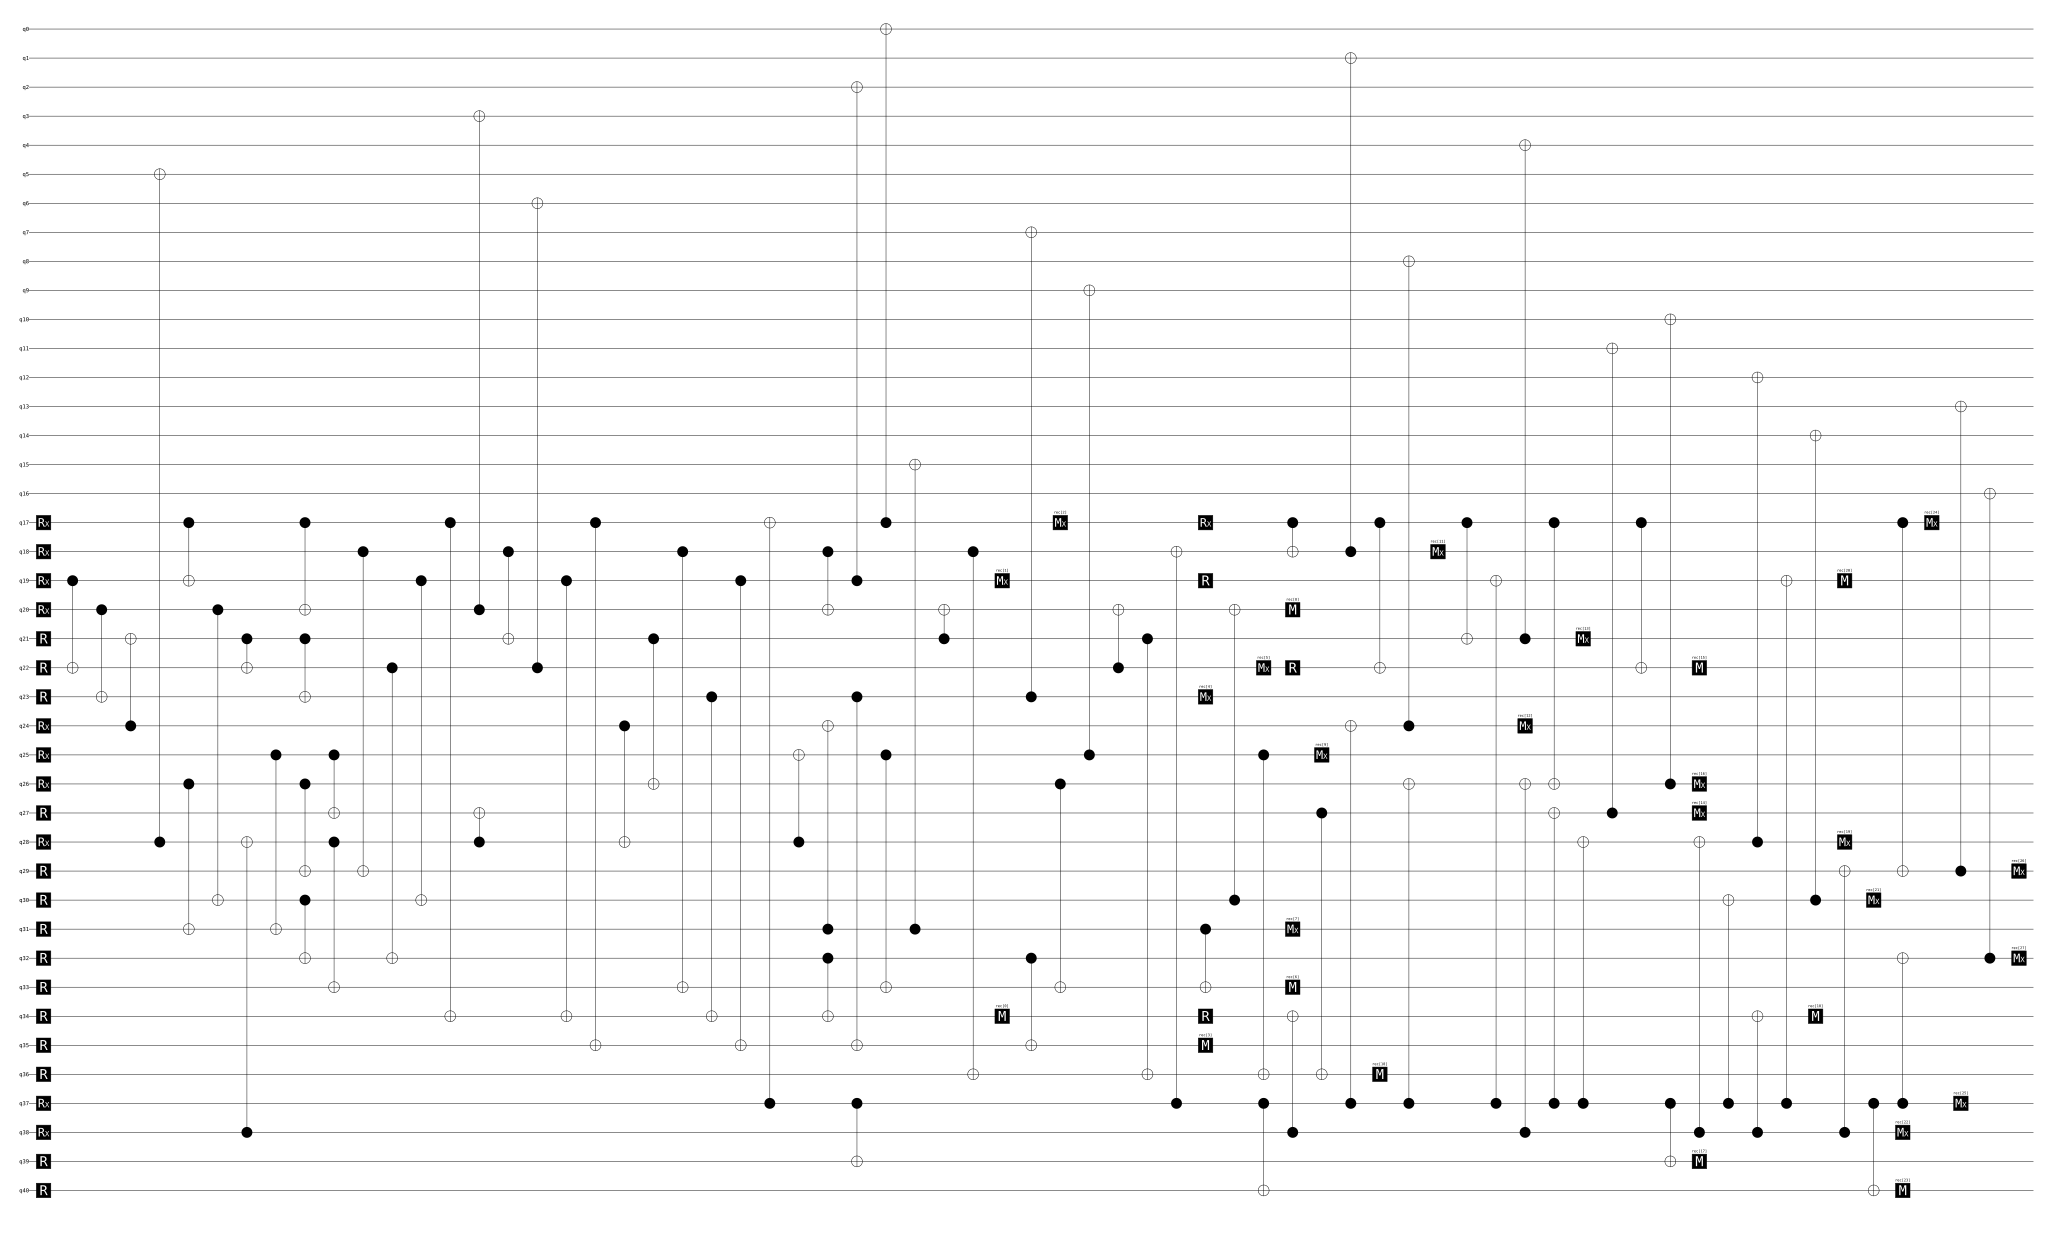

In [9]:
from spiderwarp.qubit_reuse import build_circuit_dag, inject_aggressive_reuse, apply_logical_qubit_merge_and_compress, \
    dag_to_circuit, inject_volume_optimizing_reuse

dag = build_circuit_dag(optimised, code.n)
mod_dag, logical_to_physical, total_hw = inject_volume_optimizing_reuse(dag, code.n)
compressed_dag = apply_logical_qubit_merge_and_compress(mod_dag, code.n)
final_circ, final_meas_map = dag_to_circuit(compressed_dag)

print("Number of ancilla qubits necessary:", final_circ.num_qubits - code.n)
print("Mapping of new measurements to old measurements:", final_meas_map)
final_circ.diagram('timeline-svg')

In [10]:
samples = (perfect_state + final_circ).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]

flag_indices = [k for k, v in final_meas_map.items() if v < se.num_qubits - 2 * code.n]
flags = samples[:,flag_indices].astype(int)

syndrome_indices = {k:v - se.num_qubits + 2 * code.n for k, v in final_meas_map.items() if v >= se.num_qubits - 2 * code.n}
effective_H = code.H_z[:,list(syndrome_indices.values())]
raw_syndrome_measurements = samples[:,list(syndrome_indices.keys())]
syndromes = raw_syndrome_measurements @ effective_H.T % 2

print("Flags:", flags, sep="\n", end="\n\n")

print("Syndromes:", syndromes, sep="\n")

Flags:
[[0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0]]

Syndromes:
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
